In [3]:
from google.colab import files
data=files.upload()

Saving titanic.csv to titanic.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

In [5]:
df = pd.read_csv("titanic.csv")

print("First 5 Rows:")
print(df.head())

# ==============================
# BASIC INFO
# ==============================
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ==============================
# MISSING VALUES
# ==============================
print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0        0        0       1        0        0       0.0   
2       0  ...        0        0        0       3        0        0       2.0   
3       0  ...        0        0        0       1        0        0       2.0   
4       0  ...        0        0        0       3        0        0       2.0   

   zero.17  zero.18  2urvived  
0        0      

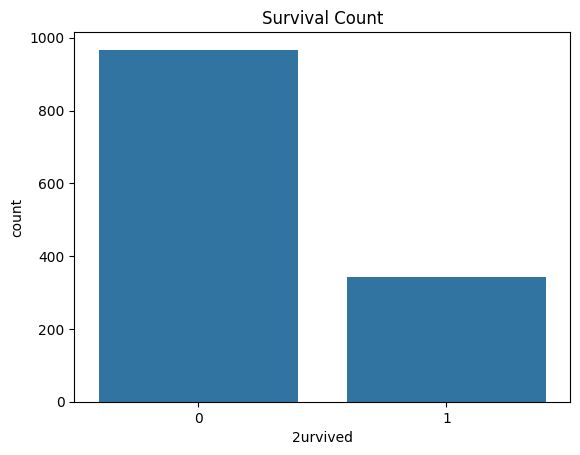

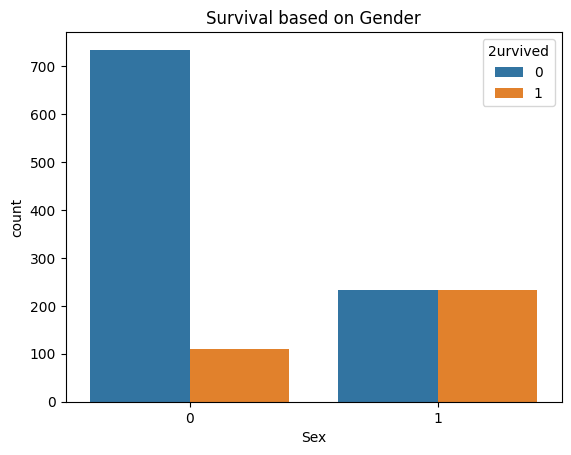

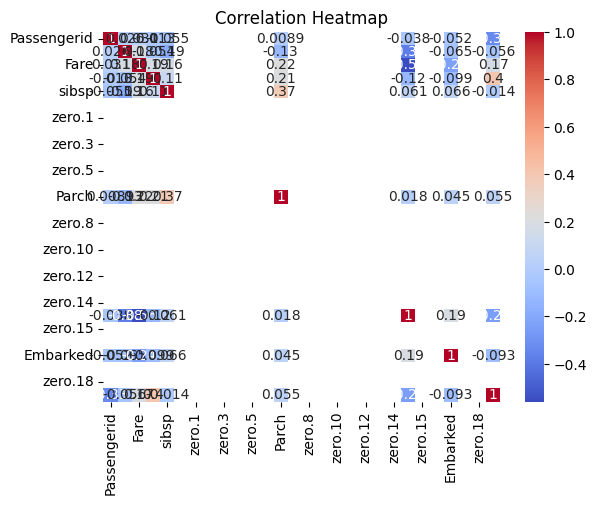

In [7]:
# ==============================
# EDA VISUALIZATION
# ==============================

# Survival Count
sns.countplot(x='2urvived', data=df)
plt.title("Survival Count")
plt.show()

# Gender vs Survival
sns.countplot(x='Sex', hue='2urvived', data=df)
plt.title("Survival based on Gender")
plt.show()

# Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# ==============================
# DATA CLEANING
# ==============================
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# The columns 'Name', 'Ticket', 'Cabin' were not found in the DataFrame
# df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# ==============================
# ENCODING
# ==============================
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [12]:
# ==============================
# FEATURE SCALING
# ==============================
scaler = StandardScaler()

df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# ==============================
# CHECK IMBALANCE
# ==============================
print("\nClass Distribution:")
print(df['2urvived'].value_counts())

# ==============================
# HANDLE IMBALANCED DATA
# ==============================
df_majority = df[df['2urvived'] == 0]
df_minority = df[df['2urvived'] == 1]

df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

print("\nBalanced Class Distribution:")
print(df_balanced['2urvived'].value_counts())


Class Distribution:
2urvived
0    967
1    342
Name: count, dtype: int64

Balanced Class Distribution:
2urvived
0    967
1    967
Name: count, dtype: int64


In [14]:
# ==============================
# DATA REDUCTION
# ==============================
df_balanced.drop('Passengerid', axis=1, inplace=True)

# ==============================
# TRAIN-TEST SPLIT
# ==============================
X = df_balanced.drop('2urvived', axis=1)
y = df_balanced['2urvived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==============================
# FINAL OUTPUT
# ==============================
print("\nData preprocessing completed successfully!")


Train Shape: (1547, 26)
Test Shape: (387, 26)

Data preprocessing completed successfully!
